Lets see how two alanine molecules orient themselves using CREST conformer generation.
To do this we will constrain the system in a spherical region using the `SphericalWall` constraint.
We start by setting up a system of two alanine molecules in a relatively small space.

## Initial imports

In [1]:
import sys
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import scm.plams as plams
from scm.conformers import ConformersJob

try:
    from scm.plams import view  # view molecule using AMSview in a Jupyter Notebook in AMS2026+

    _has_view = True
except ImpoGrtError:
    from scm.plams import plot_molecule  # plot molecule in a Jupyter Notebook in AMS2023+

    _has_view = False

    def view(molecule, ax=None, **kwargs):
        plot_molecule(molecule, ax=ax)


# This seed will used in the initial dimer creation and for the starting MD velocities in conformers generation
# Due to numerical aspects it does not guarantee full reproducibility.
seed = random.randint(1, 10000000)
print(f"Seed used for stochastic aspects is {seed}.")

# this line is not required in AMS2025+
plams.init();

Seed used for stochastic aspects is 3982282.
PLAMS working folder: /path/plams/examples/ConformersMultipleMolecules/plams_workdir.002


## Single alanine molecule

[23.03|17:00:07] Starting Xvfb...
[23.03|17:00:07] Xvfb started


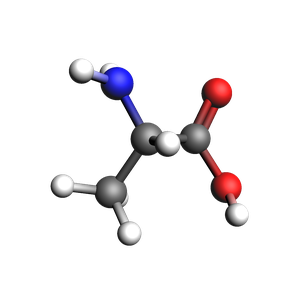

In [2]:
smiles = "CC(N)C(=O)O"
alanine = plams.from_smiles(smiles)
view(alanine, height=300, width=300)

## Initial system: alanine dimer

Pack two alanine molecules in a sphere with a density of 0.5 kg/L.

In [3]:
density = 0.5
mol = plams.packmol(alanine, n_molecules=2, density=density, sphere=True, seed=seed)

Optimize the dimer structure prior to the conformer search.

In [4]:
s = plams.Settings()
s.input.GFNFF = plams.Settings()
s.input.ams.Task = "GeometryOptimization"
s.input.ams.GeometryOptimization.Convergence.Quality = "VeryGood"
s.input.ams.GeometryOptimization.Maxiterations = 1300
s.input.ams.GeometryOptimization.Method = "Quasi-Newton"

job = plams.AMSJob(molecule=mol, settings=s)
job.run()
mol = job.results.get_main_molecule()

[23.03|17:00:15] JOB plamsjob STARTED
[23.03|17:00:15] JOB plamsjob RUNNING
[23.03|17:00:17] JOB plamsjob FINISHED
[23.03|17:00:17] JOB plamsjob SUCCESSFUL


Translate the system to be centered around the origin (needed for SphericalWall later):

In [5]:
mol.translate(-np.array(mol.get_center_of_mass()))

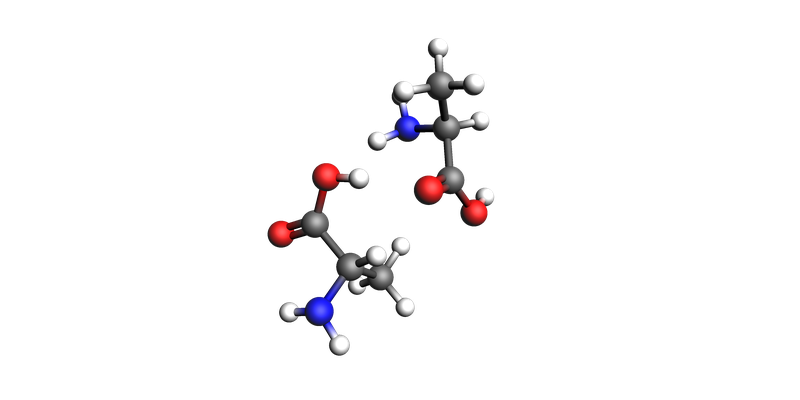

In [6]:
view(mol, direction="along_pca3")

## Calculation setup

To determine the radius of the `SphericalWall` we measure the size of the initial dimer.

In [7]:
dists = plams.distance_array(mol, mol)
max_dist = np.max(dists)
diameter = 1.33 * max_dist
radius = diameter / 2
print(f"Largest distance between atoms: {max_dist:.3f} ang.")
print(f"Radius: {radius:.3f} ang.")

Largest distance between atoms: 8.116 ang.
Radius: 5.397 ang.


Now we can set up the Crest conformer generation job, with the appropriate spherical wall constraining the molecules close together. The `NMolDynStepsFactor` keyword ensures that the metadynamics and regulat molecular dynamics simulations used in a crest exploration are three times longer than the default. The default setting is based on single molecule flexibility. For multiple molecules, a little more exploration is required.

In [8]:
nsteps = 3200

settings = plams.Settings()
settings.input.ams.EngineAddons.WallPotential.Enabled = "Yes"
settings.input.ams.EngineAddons.WallPotential.Radius = radius
settings.input.ams.Generator.Method = "CREST"
settings.input.ams.Output.KeepWorkDir = "Yes"
settings.input.ams.GeometryOptimization.MaxConvergenceTime = "High"
settings.input.ams.Generator.CREST.NCycles = 3  # at most 3 CREST cycles for this demo
settings.input.ams.Generator.RNGSeed = seed
settings.input.ams.Generator.CREST.NMolDynStepsFactor = 3
settings.input.GFNFF = plams.Settings()

## Run the conformers job

Now we can run the conformer generation job. This job will run somewhere between 30 minutes and 1 hour.

In [14]:
job = ConformersJob(molecule=mol, settings=settings)
job.run()
# job = ConformersJob.load_external("plams_workdir/conformers/conformers.rkf")  # load from disk instead of running the job

Now, remove the wall and reoptimize

In [15]:
if "EngineAddons" in settings.input.ams:
    del settings.input.ams.EngineAddons
settings.input.ams.Task = "Optimize"
settings.input.ams.InputConformersSet = job.results.rkfpath()
opt_job = ConformersJob(settings=settings)
opt_job.run()

[23.03|17:02:22] JOB conformers STARTED
[23.03|17:02:22] Renaming job conformers to conformers.002
[23.03|17:02:22] JOB conformers.002 RUNNING
[23.03|17:06:18] JOB conformers.002 FINISHED
[23.03|17:06:19] JOB conformers.002 SUCCESSFUL


In [16]:
rkf = opt_job.results.rkfpath()
print(f"Conformers stored in {rkf}")

Conformers stored in /path/plams/examples/ConformersMultipleMolecules/plams_workdir.002/conformers.002/conformers.rkf


## Results
Here we plot the three lowest-energy conformers.

In [17]:
def plot_conformers(job: ConformersJob, indices=None, temperature=298, unit="kcal/mol", lowest=True):
    molecules = job.results.get_conformers()
    energies = job.results.get_relative_energies(unit)
    populations = job.results.get_boltzmann_distribution(temperature)

    if isinstance(indices, int):
        N_plot = min(indices, len(energies))
        if lowest:
            indices = list(range(N_plot))
        else:
            indices = np.linspace(0, len(energies) - 1, N_plot, dtype=np.int32)
    if indices is None:
        indices = list(range(min(3, len(energies))))

    fig, axes = plt.subplots(1, len(indices), figsize=(12, 4))
    if len(indices) == 1:
        axes = [axes]

    for ax, i in zip(axes, indices):
        mol = molecules[i]
        E = energies[i]
        population = populations[i]

        if _has_view:
            img = view(mol, width=300, height=300)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"#{i+1}\nΔE = {E:.2f} kcal/mol\nPop.: {population:.3f} (T = {temperature} K)")
        else:
            view(mol, ax=ax)
            ax.set_title(f"#{i+1}\nΔE = {E:.2f} kcal/mol\nPop.: {population:.3f} (T = {temperature} K)")

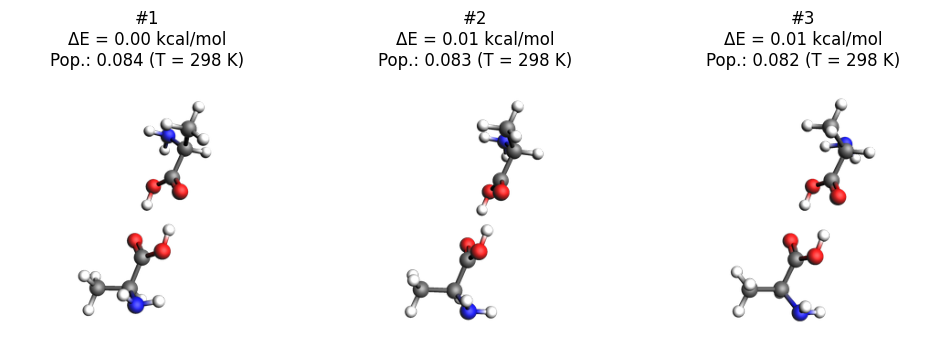

In [18]:
plot_conformers(opt_job)

You can also open the conformers in AMSmovie to browse all 1000+ conformers:

In [19]:
!amsmovie {rkf}

The `conformerset` attribute holds information about the full set of conformers.

In [20]:
conformerset = opt_job.results.conformerset
print("Number of conforrmers: ", len(conformerset))

Number of conforrmers:  3605


### Filtering out duplicates
This conformerset does not contain any duplicates. However, there is no single definition of the term duplicates when applied to conformers. By default, duplicates are defined based on energy and rotational constants, the latter quantifying the 3D shape of the system. The filtering method uses thresholds for energy and rotational constants, which have been thoroughly tested for (mostly small) single molecules systems. If the user feels that the stored conformers are too similar, these thresholds can of course be changed. Below we refilter the stored conformerset using more lenient thresholds (systems with greater differences will be considered duplicates).

In [21]:
s = plams.Settings()
s.input.ams.Task = "Filter"
s.input.ams.InputConformersSet = rkf
s.input.ams.Equivalence.CREST.EnergyThreshold = 0.2  # default is 0.05
s.input.ams.Equivalence.CREST.ScaledRotationalConstantSettings.RotationalConstantThreshold = 0.01  # default is 0.003

filter_job = ConformersJob(settings=s)
filter_job.run()
conformerset = filter_job.results.conformerset
print("Number of conformers: ", len(conformerset))

[23.03|17:07:40] JOB conformers STARTED
[23.03|17:07:40] Renaming job conformers to conformers.003
[23.03|17:07:40] JOB conformers.003 RUNNING
[23.03|17:08:20] JOB conformers.003 FINISHED
[23.03|17:08:21] JOB conformers.003 SUCCESSFUL
Number of conformers:  3306


Alternatively, a filtering method can be applied that uses more local comparisons. The native AMS duplicate filter uses the interatomic distance matrix and torsion angles to determine if two structures are duplicates. This approach may be more appropriate for systems with multiple molecules, because the method only takes into account intra-molecular changes. On the other hand, this type of filtering is more time consuming, while in most cases the effect on the conformer set will not be extreme.

In [22]:
s = plams.Settings()
s.input.ams.Task = "Filter"
s.input.ams.InputConformersSet = rkf
s.input.ams.Equivalence.Method = "AMS"

filter_job = ConformersJob(settings=s)
filter_job.run()
conformerset = filter_job.results.conformerset
print("Number of AMS conformers: ", len(conformerset))

[23.03|17:08:31] JOB conformers STARTED
[23.03|17:08:31] Renaming job conformers to conformers.004
[23.03|17:08:31] JOB conformers.004 RUNNING
[23.03|17:10:16] JOB conformers.004 FINISHED
[23.03|17:10:17] JOB conformers.004 SUCCESSFUL
Number of AMS conformers:  3589


### Analysis
Finally in AMS2025+, you can also inspect the conformer data using the JobAnalysis tool.

In [23]:
try:
    from scm.plams import JobAnalysis

    ja = (
        JobAnalysis(standard_fields=None)
        .add_job(opt_job)
        .add_field(
            "Id",
            lambda j: list(range(1, len(j.results.get_conformers()) + 1)),
            display_name="Conformer Id",
            expansion_depth=1,
        )
        .add_field(
            "Energies",
            lambda j: j.results.get_relative_energies("kcal/mol"),
            display_name="E",
            expansion_depth=1,
            fmt=".2f",
        )
        .add_field(
            "Populations",
            lambda j: j.results.get_boltzmann_distribution(298),
            display_name="P",
            expansion_depth=1,
            fmt=".3f",
        )
    )

    # Pretty-print if running in a notebook
    if "ipykernel" in sys.modules:
        ja.display_table(max_rows=20)
    else:
        print(ja.to_table())

except ImportError:
    pass

| Conformer Id | E      | P     |
|--------------|--------|-------|
| 1            | 0.00   | 0.084 |
| 2            | 0.01   | 0.083 |
| 3            | 0.01   | 0.082 |
| 4            | 0.07   | 0.074 |
| 5            | 0.10   | 0.070 |
| 6            | 0.21   | 0.059 |
| 7            | 0.23   | 0.057 |
| 8            | 0.31   | 0.050 |
| 9            | 0.31   | 0.049 |
| 10           | 0.33   | 0.048 |
| ...          | ...    | ...   |
| 3596         | 100.84 | 0.000 |
| 3597         | 101.11 | 0.000 |
| 3598         | 101.77 | 0.000 |
| 3599         | 102.06 | 0.000 |
| 3600         | 102.61 | 0.000 |
| 3601         | 103.40 | 0.000 |
| 3602         | 104.58 | 0.000 |
| 3603         | 106.33 | 0.000 |
| 3604         | 107.74 | 0.000 |
| 3605         | 111.33 | 0.000 |